<a href="https://colab.research.google.com/github/yunussfr/MSIDdetection/blob/main/EfficientNetB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# 1. VERİ YOLU (Buraya kendi veri setinin ana klasör yolunu yazmalısın)
DATA_DIR = "/content/drive/MyDrive/Monkeypox Skin Image Dataset"

# Görüntü boyutu EfficientNetB0 için standart olarak 224x224'tür.
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. VERİLERİ VE ETİKETLERİ OKUMA (Gördüğü her klasörü bir sınıf sayar)
filepaths = []
labels = []
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR, cls_name)
    for img_name in os.listdir(cls_dir):
        # Sadece resim dosyalarını alıyoruz
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(os.path.join(cls_dir, img_name))
            labels.append(class_to_idx[cls_name])

print(f"Toplam Bulunan Sınıflar: {classes}")
print(f"Toplam Görüntü Sayısı: {len(filepaths)}")

# 3. TRAIN, VALIDATION VE TEST OLARAK AYIRMA (%70 Train, %15 Val, %15 Test)
# stratify=labels parametresi, dengesiz verilerin her sete aynı oranda dağılmasını sağlar.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    filepaths, labels, test_size=0.15, stratify=labels, random_state=42
)

# Kalan %85'lik kısmı tekrar bölerek Validation'ı çıkarıyoruz
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=42
)

print(f"Eğitim (Train) seti: {len(X_train)} resim")
print(f"Doğrulama (Val) seti: {len(X_val)} resim")
print(f"Test seti: {len(X_test)} resim")

# 4. DENGESİZ VERİLER İÇİN SINIF AĞIRLIKLARINI HESAPLAMA (Ceza Sistemi)
# Az verisi olan sınıfın ağırlığı yüksek, çok verisi olanın ağırlığı düşük çıkacaktır.
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Uygulanacak Sınıf Ağırlıkları (Cezalar): {class_weight_dict}")

# 5. TF.DATA İLE YÜKSEK PERFORMANSLI VERİ BORU HATTI OLUŞTURMA
def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Not: EfficientNet modeli piksel değerlerini kendi içinde ölçeklendirir (0-255 aralığını bekler),
    # Bu yüzden manuel normalizasyon (img/255.0) YAPMIYORUZ.
    return img, label

def create_dataset(X, y, batch_size=BATCH_SIZE, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(X_train, y_train, is_training=True)
val_ds = create_dataset(X_val, y_val)
test_ds = create_dataset(X_test, y_test)

# 6. VERİ ÇOĞALTMA (Data Augmentation) - Sadece eğitim sırasında çalışır
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# 7. EFFICIENTNET MİMARİSİNİ KURMA (Transfer Learning)
# ImageNet ağırlıklarını alıyoruz, en üstteki (çıktı) katmanı almıyoruz (include_top=False)
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
# Önce hazır modeli donduruyoruz ki öğrenilmiş gözleri bozulmasın
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x) # Aşırı öğrenmeyi (ezberi) engellemek için

# Çıktı katmanı: Kaç klasör (sınıf) varsa o kadar nöron ve softmax aktivasyonu
outputs = tf.keras.layers.Dense(len(classes), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# 8. MODELİ DERLEME
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 9. EĞİTİM KONTROLCÜLERİ (Callbacks)
callbacks = [
    # Model 5 epoch boyunca validation loss'ta iyileşme göstermezse eğitimi durdur, en iyi haline dön
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    # Model tıkanırsa öğrenme oranını (learning rate) yarıya düşür
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# 10. MODELİ EĞİTME (Sınıf ağırlıkları sisteme burada dahil ediliyor)
EPOCHS = 30 # Early stopping olduğu için yüksek tutulabilir

print("\n--- Eğitim Başlıyor ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict, # <-- Azınlık sınıfların cezasını artırdığımız yer
    callbacks=callbacks
)

# 11. TEST SETİ İLE MODELİN GERÇEK BAŞARISINI ÖLÇME
print("\n--- Test Seti Değerlendirmesi ---")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Doğruluğu (Accuracy): {test_acc:.4f}")

Toplam Bulunan Sınıflar: ['Chickenpox', 'Measles', 'Monkeypox', 'Normal']
Toplam Görüntü Sayısı: 770
Eğitim (Train) seti: 538 resim
Doğrulama (Val) seti: 116 resim
Test seti: 116 resim
Uygulanacak Sınıf Ağırlıkları (Cezalar): {0: np.float64(1.7933333333333332), 1: np.float64(2.134920634920635), 2: np.float64(0.6897435897435897), 3: np.float64(0.6560975609756098)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

--- Eğitim Başlıyor ---
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.5260 - loss: 1.1851 - val_accuracy: 0.6724 - val_loss: 0.9150 - learning_rate: 0.0010
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.7249 - loss: 0.8923 - val_accuracy: 0.7500 - val_loss: 0.7277 - learning_rate: 0.0010
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.7862 - loss: 0.6991 - val_accuracy: 0.7759 - val_loss: 0.6694 - learning_rate: 0.0010
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.8160 - loss: 0.6079 - val_accuracy: 0

Test seti üzerinden tahminler yapılıyor, lütfen bekleyin...

             SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

           0       0.60      0.75      0.67        16
           1       0.52      0.79      0.63        14
           2       0.92      0.81      0.86        42
           3       1.00      0.86      0.93        44

    accuracy                           0.82       116
   macro avg       0.76      0.80      0.77       116
weighted avg       0.86      0.82      0.83       116



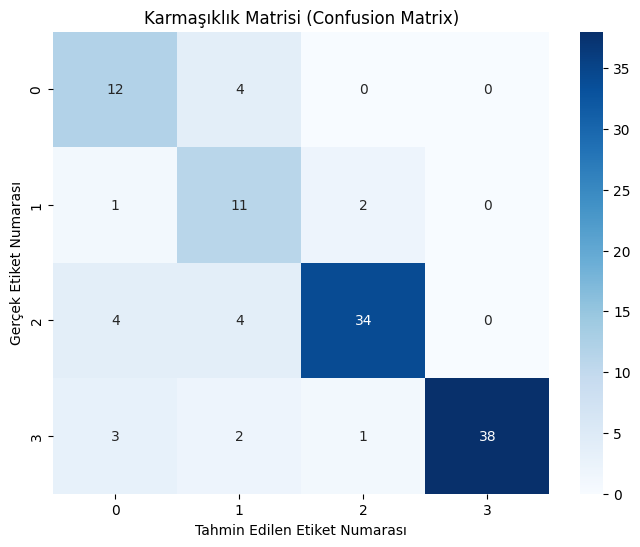

In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Test seti üzerinden tahminler yapılıyor, lütfen bekleyin...")

# 1. Test setindeki gerçek etiketleri ve modelin tahminlerini toplayalım
y_true = []
y_pred_probs = []

# test_ds üzerinden batch batch geçiyoruz
for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# 2. Olasılıkları en yüksek olan sınıfa çeviriyoruz
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. DETAYLI KARNE (HATA ÇÖZÜLDÜ: target_names parametresi kaldırıldı)
print("\n" + "="*50)
print("             SINIFLANDIRMA RAPORU")
print("="*50)
rapor = classification_report(y_true, y_pred)
print(rapor)

# 4. KARMAŞIKLIK MATRİSİ (HATA ÇÖZÜLDÜ: Eksen isimleri otomatik ayarlandı)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Etiket Numarası')
plt.xlabel('Tahmin Edilen Etiket Numarası')
plt.show()

Sistemde kullanılan temel bileşenler ve görevleri şunlardır:

Ana Omurga (EfficientNetB0): Görüntülerdeki renk, doku ve lezyon gibi özellikleri çıkarmak için kullanılır. "Bileşik Ölçeklendirme" (Compound Scaling) mekanizması sayesinde hem donanım dostudur hem de ince detayları yakalamada çok başarılıdır. İçindeki hazır ImageNet ağırlıkları kullanılarak modelin sıfırdan değil, "görmeyi öğrenmiş" olarak eğitime başlaması sağlanır.

Özelleştirilmiş Karar Katmanları: EfficientNet'in tepesine eklenen GlobalAveragePooling2D ve Dense (Tam Bağlantılı) katmanlardır. Omurgadan (filtreden) geçen verileri alıp, görüntünün hangi hastalık sınıfına ait olduğuna dair nihai olasılıkları üretir.

Veri Boru Hattı (tf.data): Fotoğrafları ve etiketleri işlemci/GPU arasında tıkanıklık yaratmadan, en verimli ve hızlı şekilde taşıyan taşıma sistemidir. Eğitim esnasında veri çoğaltma (Data Augmentation) uygulayarak modelin ezber yapmasını (overfitting) engeller.

Adil Öğrenme Sistemi (Class Weights): Veri setindeki dengesizliği çözer. Model, sayısı az olan bir hastalık sınıfını yanlış tahmin ettiğinde matematiksel olarak daha yüksek bir hata puanı (ceza) alır; böylece tembellik yapıp sadece çok gördüğü sınıfı tahmin edemez.

Akıllı Kontrol Mekanizmaları (Callbacks): Modelin eğitimini denetleyen oto-pilottur. EarlyStopping ezberleme başladığında eğitimi keser; ReduceLROnPlateau model tıkanırsa öğrenme adımlarını küçültür; ModelCheckpoint ise eğitim boyunca ulaşılan en kusursuz anı fiziksel bir dosya olarak bilgisayarına kaydeder.*